In [145]:
# The goal of this analysis is to analyze New York Police Department arrest data. 
# We will be comparing the average age group of arrests by precinct, using the 104th precinct (which contains the Queens neighborhoods of Glendale, Maspeth, Ridgewood, and Middle Village) as our comparison point to all city wide arrests.

In [146]:
# We will first import our packages.

!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [147]:
# Here we will upload our dataset from a local .csv file downloaded from NYC Open Data.
# Link to dataset: https://data.cityofnewyork.us/Public-Safety/NYPD-Arrest-Data-Year-to-Date-/uip8-fykc/about_data
df = pd.read_csv("nypdarrest.csv")

In [148]:
# To view more of our data, we will expand the display limits of results.
pd.set_option('display.max_rows', 250)
pd.set_option('display.max_columns', None)

In [149]:
# Let's take a look at our first 50 results.
df.head(50)

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
5,301989860,03/03/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,43,0,45-64,M,BLACK,1020219,239110,40.822912,-73.870041,POINT (-73.8700413043181 40.8229123084767)
6,302130401,03/05/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,43,0,25-44,M,BLACK,1020183,239282,40.823387,-73.870170,POINT (-73.87017 40.823387)
7,302254604,03/08/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,40,0,25-44,M,BLACK,1005990,233847,40.808515,-73.921467,POINT (-73.921467 40.808515)
8,302692601,03/12/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,40,0,25-44,M,BLACK,1008067,236070,40.814611,-73.913956,POINT (-73.913956 40.814611)
9,303343948,03/21/2025,153,RAPE 3,104.0,RAPE,PL 1302507,F,K,78,0,25-44,M,WHITE HISPANIC,991330,187303,40.680786,-73.974475,POINT (-73.9744751162161 40.6807856126343)


In [150]:
# Let's take a look at the columns.
df.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [151]:
# To clean up our data, let's drop some of the columns that are unnecessary for our particular analysis.
df = df.drop(columns=['KY_CD', 'JURISDICTION_CODE','X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'])
df

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE
0,299201470,01/10/2025,105,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,F,Q,110,25-44,F,WHITE
1,299351927,01/13/2025,105,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,F,S,120,25-44,M,BLACK
2,299366743,01/13/2025,157,RAPE 1,RAPE,PL 130351A,F,B,46,25-44,M,BLACK HISPANIC
3,300990163,02/12/2025,153,RAPE 3,RAPE,PL 1302504,F,K,77,(null),(null),BLACK
4,301010124,02/12/2025,157,RAPE 1,RAPE,PL 130353A,F,K,77,25-44,M,BLACK
...,...,...,...,...,...,...,...,...,...,...,...,...
278948,318159497,12/30/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",PETIT LARCENY,PL 1552500,M,K,70,(null),(null),BLACK
278949,318206208,12/31/2025,101,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,25,25-44,F,BLACK
278950,318144122,12/30/2025,101,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,110,18-24,F,BLACK
278951,318209021,12/31/2025,779,"PUBLIC ADMINISTRATION,UNCLASSI",MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,25-44,M,BLACK HISPANIC


In [152]:
# Let's analyze the precincts.
# This line of code will tell us how many precincts we are dealing with.
df['ARREST_PRECINCT'].nunique()

78

In [153]:
# Of the 78, let's see where the 104th places.
sortedprecincts = df.groupby(['ARREST_PRECINCT'])['ARREST_KEY'].count().sort_values(ascending=False)
sortedprecincts

ARREST_PRECINCT
14     10364
40      9244
75      9039
44      7863
103     7803
46      7230
120     6264
73      6050
47      5942
52      5790
110     5784
67      5591
18      5574
60      5391
115     5049
43      4945
41      4851
1       4634
114     4541
48      4480
113     4464
109     4450
79      4353
42      4311
83      4308
70      4054
5       3947
34      3947
13      3936
84      3873
72      3787
102     3574
77      3569
25      3507
49      3346
62      3159
28      3085
32      3070
45      3038
116     2983
81      2955
23      2879
107     2754
61      2709
121     2706
106     2668
71      2660
101     2657
19      2542
33      2522
90      2508
68      2456
78      2431
112     2408
6       2393
104     2335
105     2290
108     2273
63      2203
9       2155
66      2143
7       2106
24      1979
69      1924
10      1890
30      1804
50      1795
76      1784
122     1763
88      1628
20      1364
26      1360
94      1301
17      1214
100     1172
123      

In [154]:
# We can see that the 104th sits in 56th place with 2,335 documented arrests.
# let's analyze our age data, first by sorting by age group.
ages = df.groupby(['AGE_GROUP'])['ARREST_KEY'].count().sort_values(ascending=False)
ages

AGE_GROUP
(null)    147237
25-44      77063
45-64      29326
18-24      17786
<18         4766
65+         2775
Name: ARREST_KEY, dtype: int64

In [155]:
# We can see that the majority of our 278,952 arrests have ages listed as (null).
# For our age group analyses we will drop the (null) values.
agesdf = df[df['AGE_GROUP'] != '(null)']
agesdf

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE
0,299201470,01/10/2025,105,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,F,Q,110,25-44,F,WHITE
1,299351927,01/13/2025,105,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,F,S,120,25-44,M,BLACK
2,299366743,01/13/2025,157,RAPE 1,RAPE,PL 130351A,F,B,46,25-44,M,BLACK HISPANIC
4,301010124,02/12/2025,157,RAPE 1,RAPE,PL 130353A,F,K,77,25-44,M,BLACK
5,301989860,03/03/2025,157,RAPE 1,RAPE,PL 130351A,F,B,43,45-64,M,BLACK
...,...,...,...,...,...,...,...,...,...,...,...,...
278946,318166245,12/30/2025,503,"CONTROLLED SUBSTANCE,INTENT TO",DANGEROUS DRUGS,PL 2201601,F,B,41,25-44,M,WHITE HISPANIC
278947,318192911,12/31/2025,113,"MENACING,UNCLASSIFIED",ASSAULT 3 & RELATED OFFENSES,PL 1201500,M,Q,113,25-44,M,BLACK
278949,318206208,12/31/2025,101,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,M,25,25-44,F,BLACK
278950,318144122,12/30/2025,101,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,110,18-24,F,BLACK


In [156]:
# Now we have 131,716 rows to work with.
# Let's analyze the age breakdown of the 104th precinct arrests.
ages104 = agesdf[agesdf["ARREST_PRECINCT"] == 104]
ages104

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX,PERP_RACE
1322,299057994,01/08/2025,244,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,PL 1402501,F,Q,104,25-44,M,BLACK
1735,300245068,01/29/2025,113,"MENACING,UNCLASSIFIED",ASSAULT 3 & RELATED OFFENSES,PL 1201401,M,Q,104,25-44,M,WHITE
2549,299262238,01/11/2025,105,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,F,Q,104,25-44,M,BLACK HISPANIC
3077,299964693,01/24/2025,779,"PUBLIC ADMINISTRATION,UNCLASSI",MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,104,25-44,M,WHITE HISPANIC
3103,299509810,01/15/2025,101,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,Q,104,<18,F,ASIAN / PACIFIC ISLANDER
...,...,...,...,...,...,...,...,...,...,...,...,...
277793,317951421,12/25/2025,339,"LARCENY,PETIT FROM OPEN AREAS,",PETIT LARCENY,PL 1552500,M,Q,104,25-44,M,BLACK
277810,317322319,12/10/2025,514,"CONTROLLED SUBSTANCE,SALE 2",DANGEROUS DRUGS,PL 2204101,F,Q,104,45-64,M,WHITE HISPANIC
277817,317363074,12/11/2025,105,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,F,Q,104,45-64,M,BLACK
278166,318198593,12/31/2025,113,"MENACING,UNCLASSIFIED",ASSAULT 3 & RELATED OFFENSES,PL 1201401,M,Q,104,45-64,M,WHITE


In [157]:
# Let's isolate the age group column.
ages104group = ages104.groupby(['AGE_GROUP'])['ARREST_KEY'].count()
ages104group

AGE_GROUP
18-24    192
25-44    771
45-64    247
65+       32
<18       52
Name: ARREST_KEY, dtype: int64

In [158]:
# Now let's do the same for the full dataset.
agesdfgroup = agesdf.groupby(['AGE_GROUP'])['ARREST_KEY'].count()
agesdfgroup

AGE_GROUP
18-24    17786
25-44    77063
45-64    29326
65+       2775
<18       4766
Name: ARREST_KEY, dtype: int64

Text(0, 0.5, 'Number of Arrests')

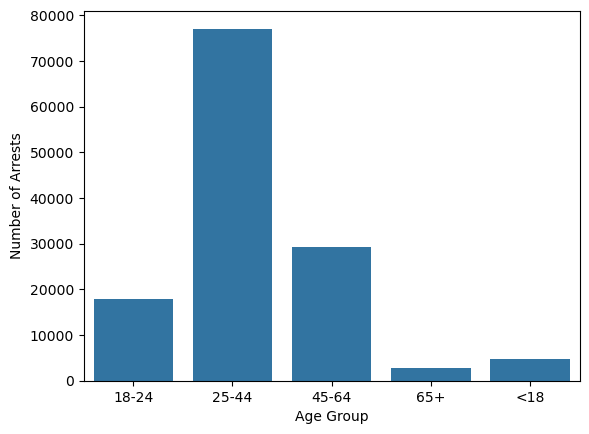

In [159]:
# Let's make a barplot of our citywide data.
sns.barplot(data=agesdfgroup)
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')

Text(0, 0.5, 'Number of Arrests')

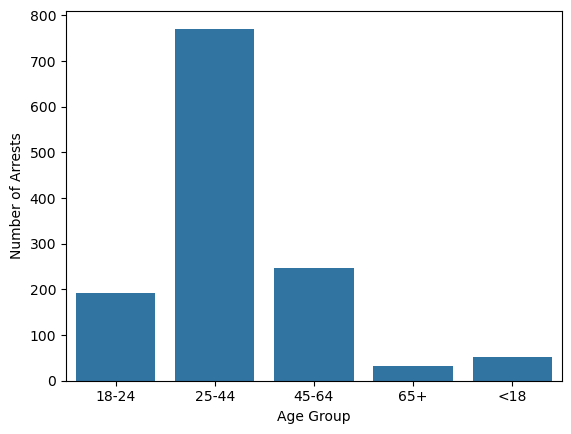

In [160]:
# And now one of our 104th data.
sns.barplot(data=ages104group)
plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')

In [161]:
# In both plots, age groups from highest-to-lowest are: 25-44, 45-64, 18-24, <18, 65+.
# However, it is difficult to tell if the ratios of arrests by age for the 104th precinct are close to citywide trends.
# We can produce easier to compare results by converting results into percentages.
# By dividing our age group results by the total amount of arrests and multiplying by 100, we can get percentages.
# As a reminder, after removing null values for age groups, there are 1,294 arrests for the 104th precinct and 131,716 arrests citywide.
p104 = ages104group/1294 * 100
p104

AGE_GROUP
18-24    14.837713
25-44    59.582689
45-64    19.088099
65+       2.472952
<18       4.018547
Name: ARREST_KEY, dtype: float64

In [162]:
pall = agesdfgroup/131716 * 100
pall

AGE_GROUP
18-24    13.503295
25-44    58.506939
45-64    22.264569
65+       2.106806
<18       3.618391
Name: ARREST_KEY, dtype: float64

In [163]:
# Before making pie charts to visualize the data, let's make a labels set.
labels = ["18-24", "25-44", "45-64", "65+", "<18"]

Text(0.5, 1.0, 'Arrests by Age Group in NYPDs 104th Precinct (Year to Date)')

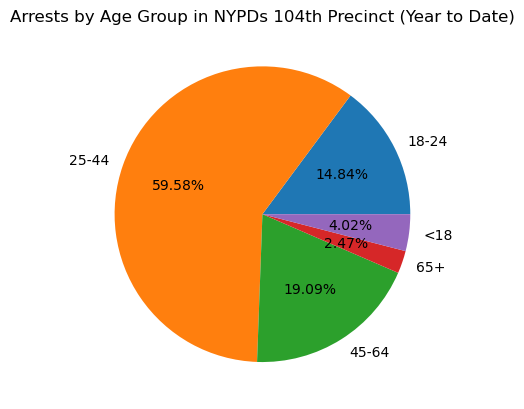

In [164]:
# Now let's make a pie chart our percentages for the 104th.
plt.pie(p104, labels=labels, autopct='%1.2f%%')
plt.title('Arrests by Age Group in NYPDs 104th Precinct (Year to Date)')

Text(0.5, 1.0, 'Arrests by Age Group in New York City (Year to Date)')

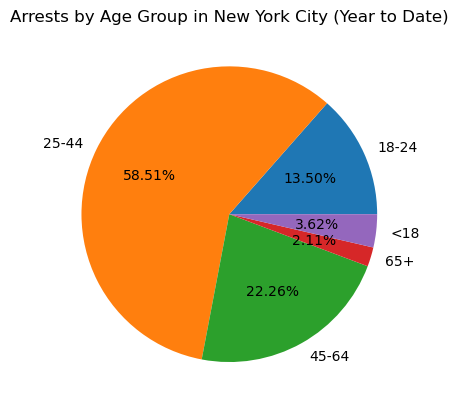

In [165]:
# Now a pie chart for city wide percentages.
plt.pie(pall, labels=labels, autopct='%1.2f%%')
plt.title('Arrests by Age Group in New York City (Year to Date)')

In [166]:
# While the numbers do give us the answer we were looking for, we can go one step further and create a bar graph that will visualize the differences.
# To do so, we will first merge the percentage sets together.
merge = pd.merge(p104, pall, on="AGE_GROUP")
merge

,ARREST_KEY_x,ARREST_KEY_y
AGE_GROUP,,
18-24,14.837713,13.503295
25-44,59.582689,58.506939
45-64,19.088099,22.264569
65+,2.472952,2.106806
<18,4.018547,3.618391


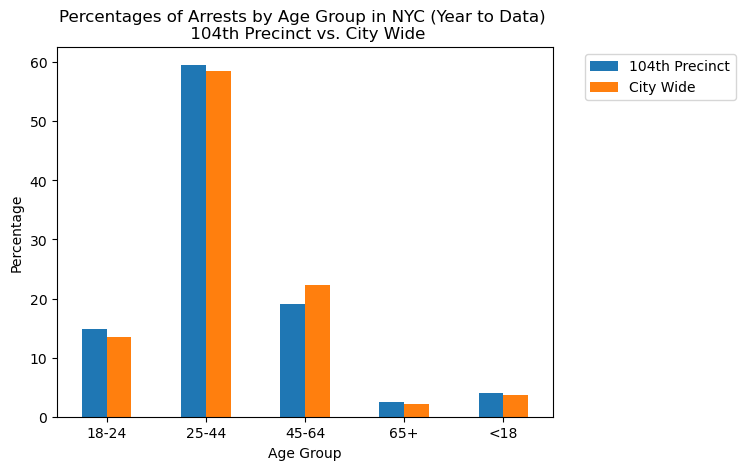

In [167]:
# Now they are merged, we can graph them together.
ax = merge.plot(kind='bar', rot=0)
ax.legend(['104th Precinct', 'City Wide'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Percentages of Arrests by Age Group in NYC (Year to Data) \n 104th Precinct vs. City Wide')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.show()

In [168]:
# From our results, we can see that the percentage of 104th precinct arrests by age group trends very similarly to city wide arrests, with the 25-44 age group being the majority of arrests for both.
# The 45-64 age group is the only age group that has a lower percentage of arrests in the 104th compared to city wide, at 19.09% compared to 22.26%. It would be interesting to compare these results to the total number of NYC residents, to see if the 104th in particular possibly has a lower percentage of that age group in its population.
# It is also essential to acknowledge that more than half of the recorded arrests were cleaned from the data due to their (null) value for age group. 
# There is potential for bias in the way that the age groups were segmented, as there were not equal amounts of ages in each group (NYPD may have their own reasons to segment age groups as such).